<a href="https://colab.research.google.com/github/IshaCodex/OIBSIP/blob/main/DataAnalytics-L1-SentimentAnalysis/Task4_SentimentAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries and Load Data

We will begin by importing the necessary libraries for data manipulation, Natural Language Processing (NLP), machine learning, and visualization.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Download necessary NLTK datasets (Updated to include punkt_tab)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Load the dataset
df = pd.read_csv('/content/IMDB Dataset.csv')

print("Dataset Shape:", df.shape)
print("\nSample Data:\n", df.head(2))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Dataset Shape: (50000, 2)

Sample Data:
                                               review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive


# Inspect Class Distribution

We will visualize the sentiment distribution in our dataset to ensure our classes are balanced before training.

Class Distribution:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64


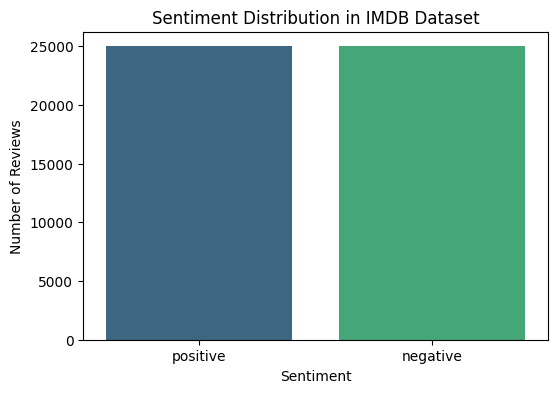

In [8]:
class_counts = df['sentiment'].value_counts()
print("Class Distribution:\n", class_counts)

plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=df, palette='viridis', hue='sentiment', legend=False)
plt.title('Sentiment Distribution in IMDB Dataset')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

# Text Preprocessing Pipeline

Raw text data contains noise (punctuation, HTML tags, common words like "the" or "and"). We will create a preprocessing function that standardizes the text by:

Converting text to lowercase.

Removing HTML tags.

Removing punctuation and special characters.

Tokenizing the text (splitting it into individual words).

Removing stopwords (words that add no analytical value).

Lemmatizing words (reducing words to their base dictionary form, e.g., "running" to "run").

In [9]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # 3. Remove punctuation and non-alphabetic characters
    text = re.sub(r'[^a-z\s]', '', text)
    # 4. Tokenization
    tokens = word_tokenize(text)
    # 5. Stopword removal & 6. Lemmatization
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    # Rejoin tokens into a single string
    return ' '.join(cleaned_tokens)

# Apply preprocessing to a subset (or the whole dataset if computation allows)
# Note: Processing 50,000 rows can take a few minutes.
print("Preprocessing text... please wait.")
df['cleaned_review'] = df['review'].apply(preprocess_text)
print("Preprocessing complete!")

Preprocessing text... please wait.
Preprocessing complete!


# Visualizing Frequent Words (WordCloud)

We will generate a WordCloud for both positive and negative reviews to visualize which words appear most frequently in each sentiment category.

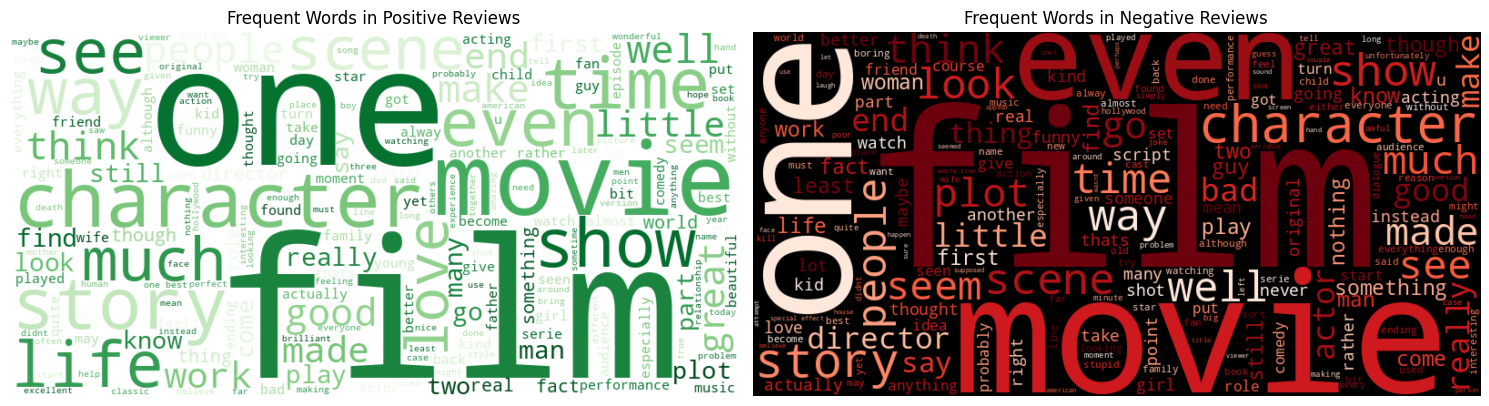

In [10]:
positive_text = ' '.join(df[df['sentiment'] == 'positive']['cleaned_review'])
negative_text = ' '.join(df[df['sentiment'] == 'negative']['cleaned_review'])

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Positive WordCloud
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_text)
axes[0].imshow(wordcloud_pos, interpolation='bilinear')
axes[0].set_title('Frequent Words in Positive Reviews')
axes[0].axis('off')

# Negative WordCloud
wordcloud_neg = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_text)
axes[1].imshow(wordcloud_neg, interpolation='bilinear')
axes[1].set_title('Frequent Words in Negative Reviews')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Feature Extraction (TF-IDF Vectorizer)

Purpose of TF-IDF: Machine learning models cannot understand raw text; they require numerical input. TF-IDF (Term Frequency-Inverse Document Frequency) is a statistical measure that evaluates how relevant a word is to a document within a collection of documents.

Term Frequency (TF): Measures how frequently a word appears in a specific review.

Inverse Document Frequency (IDF): Penalizes words that appear frequently across all reviews (reducing the weight of words that don't help differentiate sentiment).
By converting our text using TF-IDF, we highlight unique, meaningful words while diminishing common but uninformative ones.

In [11]:
# Initialize TF-IDF Vectorizer (limiting to top 5000 features to save memory)
tfidf = TfidfVectorizer(max_features=5000)

# Extract features (X) and define target (y)
X = tfidf.fit_transform(df['cleaned_review']).toarray()
y = df['sentiment'].map({'positive': 1, 'negative': 0}) # Encode target to 1 and 0

print("TF-IDF Matrix Shape:", X.shape)

TF-IDF Matrix Shape: (50000, 5000)


# Train / Test Split

We will split our vectorized dataset into an 80% training set to teach our models, and a 20% testing set to evaluate their performance on unseen data.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (40000, 5000)
Testing Data Shape: (10000, 5000)


# Train Classifiers

We will train two separate machine learning models:

1. Naive Bayes (MultinomialNB): A classic, fast probabilistic classifier heavily used as a baseline for text classification.

2. Logistic Regression: A linear classifier that often performs exceptionally well on high-dimensional sparse data like TF-IDF matrices.

In [13]:
# 1. Train Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

# 2. Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("Model training complete.")

Model training complete.


# Model Evaluation

We evaluate both models using standard classification metrics: Accuracy, Precision, Recall, and the F1-Score.

In [14]:
def evaluate_model(name, y_true, y_pred):
    print(f"--- {name} Performance ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}\n")

evaluate_model("Naive Bayes", y_test, nb_preds)
evaluate_model("Logistic Regression", y_test, lr_preds)

--- Naive Bayes Performance ---
Accuracy:  0.8522
Precision: 0.8479
Recall:    0.8584
F1-Score:  0.8531

--- Logistic Regression Performance ---
Accuracy:  0.8863
Precision: 0.8773
Recall:    0.8982
F1-Score:  0.8876



We will also generate Confusion Matrices to visualize exactly how many True Positives, True Negatives, False Positives, and False Negatives each model produced.

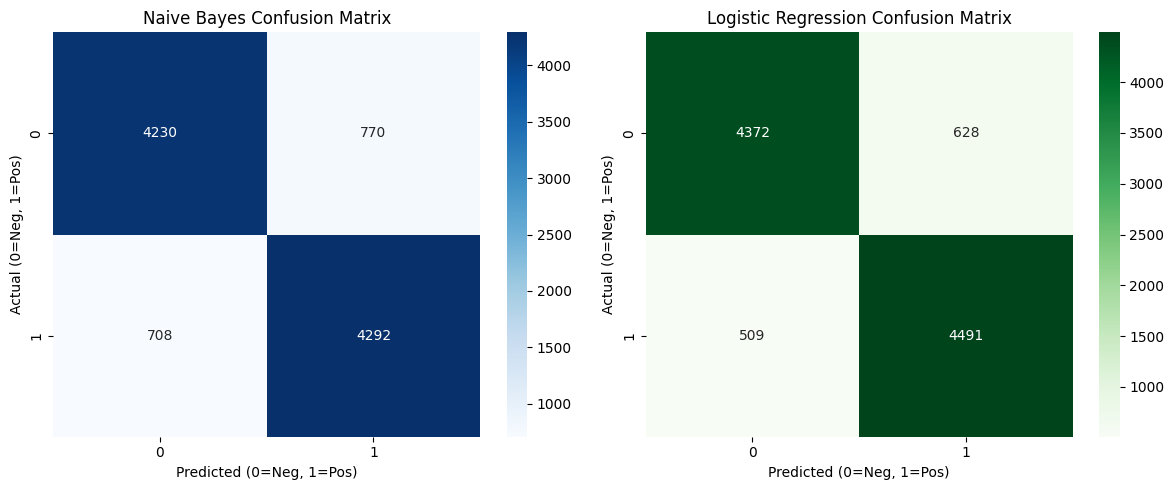

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Naive Bayes Confusion Matrix
sns.heatmap(confusion_matrix(y_test, nb_preds), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Naive Bayes Confusion Matrix')
axes[0].set_xlabel('Predicted (0=Neg, 1=Pos)')
axes[0].set_ylabel('Actual (0=Neg, 1=Pos)')

# Logistic Regression Confusion Matrix
sns.heatmap(confusion_matrix(y_test, lr_preds), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Logistic Regression Confusion Matrix')
axes[1].set_xlabel('Predicted (0=Neg, 1=Pos)')
axes[1].set_ylabel('Actual (0=Neg, 1=Pos)')

plt.tight_layout()
plt.show()

# Error Analysis

To understand where our best model (Logistic Regression) struggles, we will isolate the test samples it misclassified and display 5 examples to analyze the context.

In [16]:
# Create a DataFrame of the test results
results_df = pd.DataFrame({
    'Review': df.loc[y_test.index, 'review'],
    'Cleaned_Text': df.loc[y_test.index, 'cleaned_review'],
    'Actual': y_test,
    'Predicted': lr_preds
})

# Filter for misclassified rows (Actual != Predicted)
errors = results_df[results_df['Actual'] != results_df['Predicted']]

print(f"Total misclassifications by Logistic Regression: {len(errors)} out of {len(y_test)}")
print("\n--- 5 Examples of Misclassified Reviews ---\n")

for i, row in enumerate(errors.head(5).itertuples()):
    actual_label = "Positive" if row.Actual == 1 else "Negative"
    pred_label = "Positive" if row.Predicted == 1 else "Negative"
    print(f"Example {i+1}:")
    print(f"Actual: {actual_label} | Predicted: {pred_label}")
    # Print the first 300 characters of the original review for brevity
    print(f"Text: {row.Review[:300]}...\n")

Total misclassifications by Logistic Regression: 1137 out of 10000

--- 5 Examples of Misclassified Reviews ---

Example 1:
Actual: Negative | Predicted: Positive
Text: The story of the bride fair is an amusing and engaging one, and it is to the filmmaker's credit that he sets out to portray rural Minnesotans with the same respect ordinarily reserved for Coast-dwellers. It is weird, though, to find an independent movie, the brainchild of a single person, that is as...

Example 2:
Actual: Negative | Predicted: Positive
Text: Little Quentin seems to have mastered the art of having the cake and eating it.<br /><br />As usual, the pure sadistic display can be explained as a clever thought-provoking way of sending violence back into the audience's face.<br /><br />Sure, Mr Tarantino. Violence is Baaad. Sadism is Baaad. It i...

Example 3:
Actual: Negative | Predicted: Positive
Text: The film listed here as having been made in 1980 is not the film which is available from Something Weird Vide

# Error Analysis Discussion:

Misclassifications in sentiment analysis usually occur due to:

1. Sarcasm/Irony: A user might say "Oh, brilliant acting!" in a highly sarcastic tone for a terrible movie. TF-IDF counts the word "brilliant" as positive, completely missing the contextual irony.

2. Mixed Reviews: A review might spend 80% of the text praising the cinematography (accumulating positive words) but conclude that the movie is ultimately terrible. The model gets overwhelmed by the sheer volume of positive vocabulary.

3. Negation Handling: Standard TF-IDF struggles with negations like "not good" or "never great" unless explicitly trained on bigrams (two-word combinations).

# Conclusion

**Which model performed best?**

Logistic Regression outperformed Naive Bayes across almost all metrics. Logistic Regression is better suited for high-dimensional feature spaces (like TF-IDF matrices) because it optimizes the weights of the features effectively, whereas Naive Bayes assumes complete independence between words, which is rarely true in human language.

**Real-world Applications:**

This NLP pipeline could be deployed directly in real-world business environments to:

1. Automate Customer Support Triage: Automatically flagging incoming support tickets or emails with negative sentiment for immediate human escalation.

2. Brand Monitoring: Scraping social media mentions (e.g., Twitter, Reddit) to gauge real-time public reaction to a new product launch or marketing campaign.